In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [6]:
matches = pd.read_csv('ipl-matches.csv')
deliveries = pd.read_csv('deliveries.csv')
matches.head()


,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,29-05-2022,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,27-05-2022,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,25-05-2022,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,24-05-2022,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,22-05-2022,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [13]:

conn = sqlite3.connect('ipl.db')

matches.to_sql('matches', conn, if_exists='replace', index=False)
deliveries.to_sql('deliveries', conn, if_exists='replace', index=False)

print("Database ready!")

Database ready!


In [7]:
matches.shape

(950, 20)

In [8]:
deliveries.shape

(150460, 21)

In [11]:
matches.isnull().sum()

ID                   0
City                51
Date                 0
Season               0
MatchNumber          0
Team1                0
Team2                0
Venue                0
TossWinner           0
TossDecision         0
SuperOver            4
WinningTeam          4
WonBy                0
Margin              18
method             931
Player_of_Match      4
Team1Players         0
Team2Players         0
Umpire1              0
Umpire2              0
dtype: int64

In [14]:
deliveries.isnull().sum()   

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64

==========Most Winning Team===========

In [ ]:

query = """
    SELECT WinningTeam, COUNT(*) as total_wins
    FROM matches
    WHERE WinningTeam IS NOT NULL
    GROUP BY WinningTeam
    ORDER BY total_wins DESC
    LIMIT 10
"""
top_teams = pd.read_sql_query(query, conn)
print(top_teams)

                   WinningTeam  total_wins
0               Mumbai Indians         131
1          Chennai Super Kings         121
2        Kolkata Knight Riders         114
3  Royal Challengers Bangalore         109
4             Rajasthan Royals          96
5              Kings XI Punjab          88
6          Sunrisers Hyderabad          75
7             Delhi Daredevils          67
8               Delhi Capitals          36
9              Deccan Chargers          29


C:\Users\anish\AppData\Local\Temp\ipykernel_17008\1656876431.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_teams, x='WinningTeam', y='total_wins', palette='viridis')


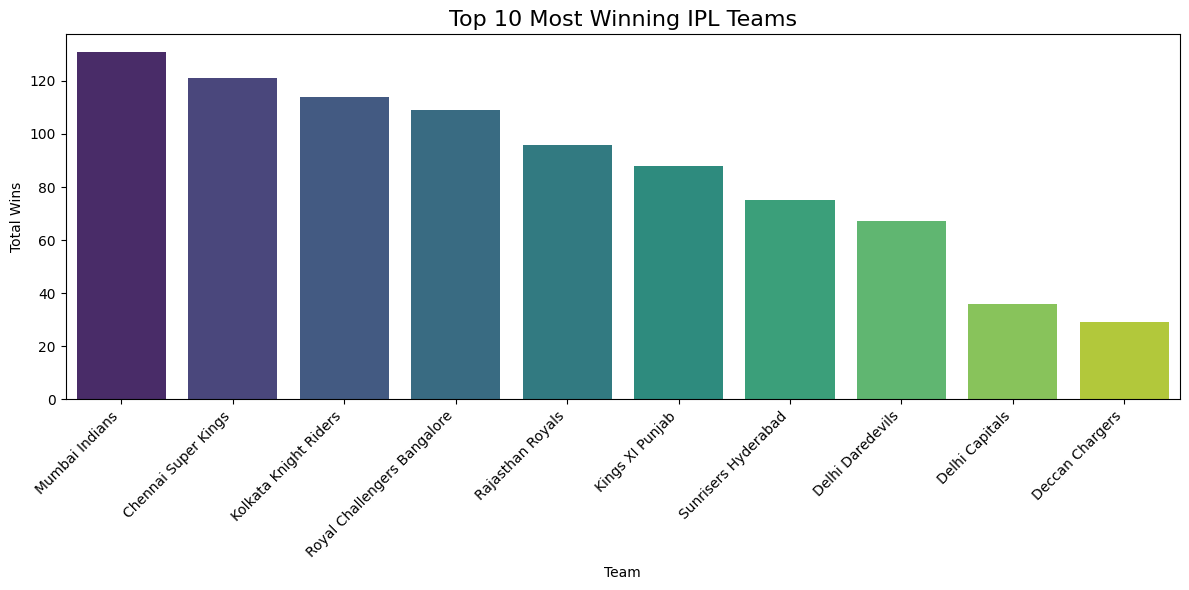

In [16]:

plt.figure(figsize=(12, 6))
sns.barplot(data=top_teams, x='WinningTeam', y='total_wins', palette='viridis')
plt.title('Top 10 Most Winning IPL Teams', fontsize=16)
plt.xlabel('Team')
plt.ylabel('Total Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

============Does winning the toss help win the match?==========


In [17]:
query = """
    SELECT TossWinner,
           COUNT(*) as total_matches,
           SUM(CASE WHEN TossWinner = WinningTeam THEN 1 ELSE 0 END) as toss_and_match_won
    FROM matches
    WHERE WinningTeam IS NOT NULL
    GROUP BY TossWinner
    ORDER BY total_matches DESC
    LIMIT 10
"""
toss_impact = pd.read_sql_query(query, conn)
print(toss_impact)


                    TossWinner  total_matches  toss_and_match_won
0               Mumbai Indians            123                  70
1        Kolkata Knight Riders            114                  64
2          Chennai Super Kings            109                  68
3  Royal Challengers Bangalore            104                  53
4             Rajasthan Royals             97                  49
5              Kings XI Punjab             85                  36
6             Delhi Daredevils             79                  35
7          Sunrisers Hyderabad             74                  34
8              Deccan Chargers             43                  19
9               Delhi Capitals             36                  21


<Figure size 1200x600 with 0 Axes>

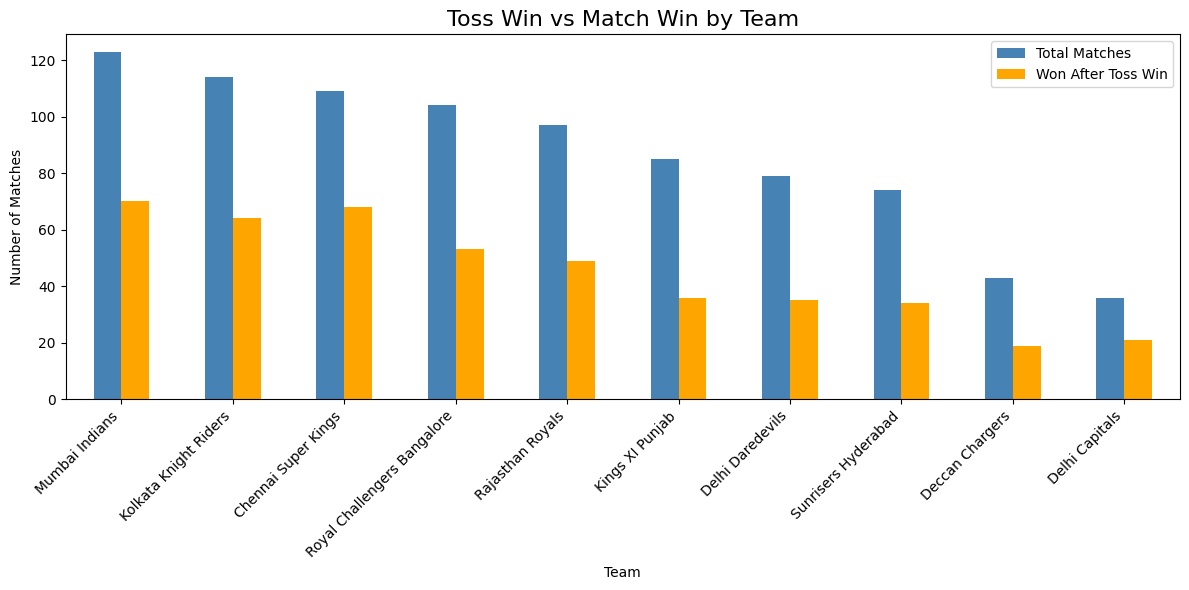

In [18]:
# Toss impact chart
plt.figure(figsize=(12, 6))
toss_impact.plot(x='TossWinner', y=['total_matches', 'toss_and_match_won'], 
                 kind='bar', figsize=(12, 6), color=['steelblue', 'orange'])
plt.title('Toss Win vs Match Win by Team', fontsize=16)
plt.xlabel('Team')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45, ha='right')
plt.legend(['Total Matches', 'Won After Toss Win'])
plt.tight_layout()
plt.show()

==========Top 10 Run Scorers of All Time============


In [19]:
query = """
    SELECT batsman, SUM(batsman_runs) as total_runs
    FROM deliveries
    GROUP BY batsman
    ORDER BY total_runs DESC
    LIMIT 10
"""
top_scorers = pd.read_sql_query(query, conn)
print(top_scorers)


          batsman  total_runs
0        SK Raina        4548
1         V Kohli        4423
2       RG Sharma        4207
3       G Gambhir        4132
4       DA Warner        4014
5      RV Uthappa        3778
6        CH Gayle        3651
7        S Dhawan        3561
8        MS Dhoni        3560
9  AB de Villiers        3486


C:\Users\anish\AppData\Local\Temp\ipykernel_17008\2866121503.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_scorers, y='batsman', x='total_runs', palette='magma')


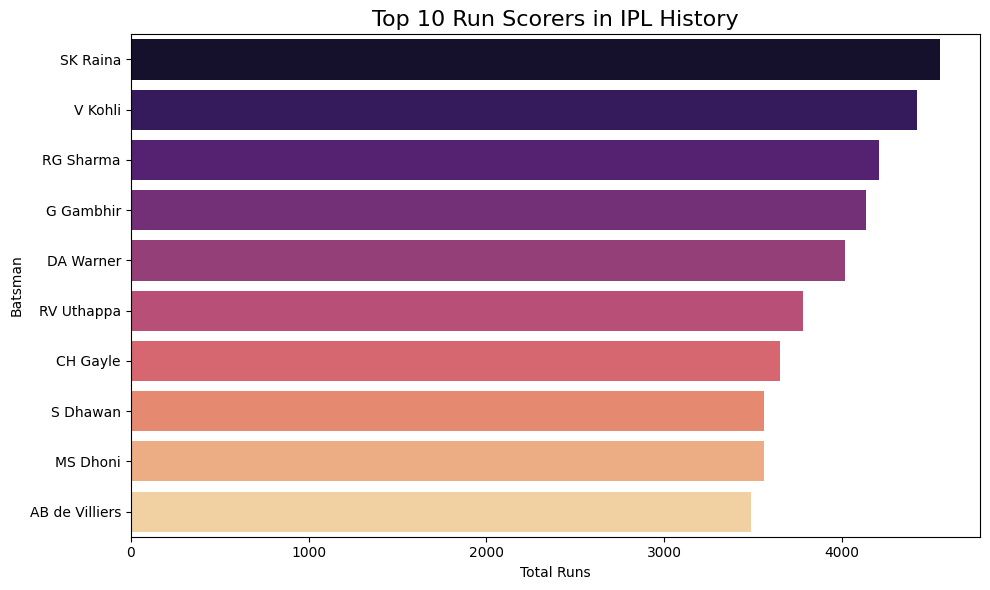

In [20]:
# Top 10 Run Scorers - Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=top_scorers, y='batsman', x='total_runs', palette='magma')
plt.title('Top 10 Run Scorers in IPL History', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

=========== Top 10 Wicket Takers of All Time ===========


In [21]:
query = """
    SELECT bowler, COUNT(*) as total_wickets
    FROM deliveries
    WHERE player_dismissed IS NOT NULL
    AND dismissal_kind NOT IN ('run out', 'retired hurt', 'obstructing the field')
    GROUP BY bowler
    ORDER BY total_wickets DESC
    LIMIT 10
"""
top_wickets = pd.read_sql_query(query, conn)
print(top_wickets)


            bowler  total_wickets
0       SL Malinga            154
1         A Mishra            134
2  Harbhajan Singh            127
3        PP Chawla            126
4         DJ Bravo            122
5          B Kumar            111
6          A Nehra            106
7    R Vinay Kumar            103
8           Z Khan            102
9         R Ashwin            100


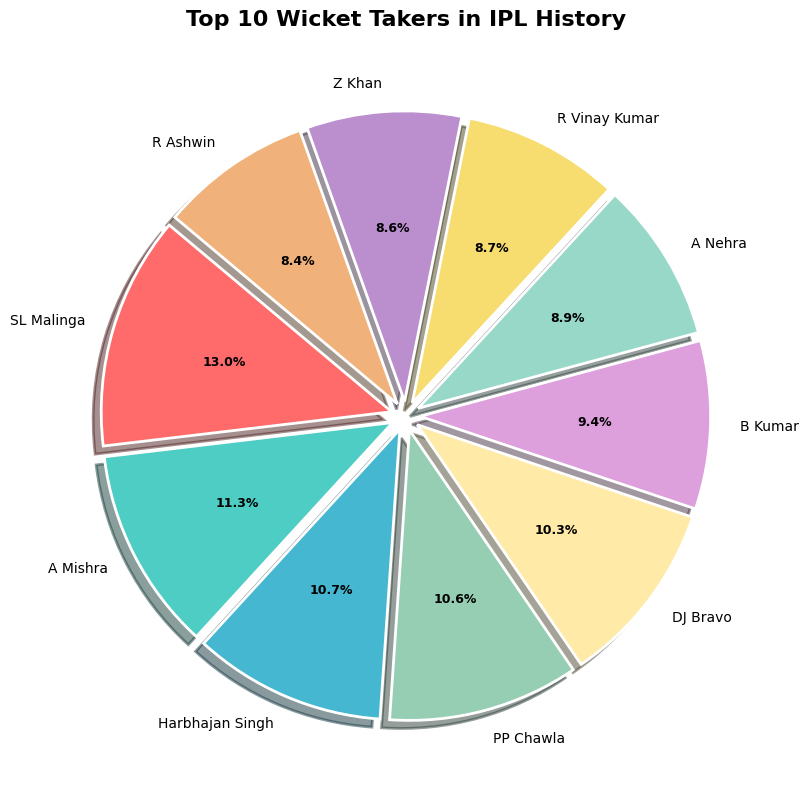

In [ ]:
# Top 10 Wicket Takers - 3D Pie Chart
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Data
sizes = top_wickets['total_wickets']
labels = top_wickets['bowler']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7',
          '#DDA0DD', '#98D8C8', '#F7DC6F', '#BB8FCE', '#F0B27A']

# 3D pie workaround
theta = 0
for i, (size, label, color) in enumerate(zip(sizes, labels, colors)):
    angle = size / sizes.sum() * 360
    wedge = plt.matplotlib.patches.Wedge(
        center=(0, 0), r=1,
        theta1=theta, theta2=theta + angle,
        facecolor=color, edgecolor='white', linewidth=2
    )
    theta += angle

plt.close()
fig, ax = plt.subplots(figsize=(12, 8))
explode = [0.05] * 10

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=140,
    shadow=True,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)

for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')

plt.title('Top 10 Wicket Takers in IPL History', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

=========== Most Sixes by Player ============


In [26]:
query = """
    SELECT batsman, COUNT(*) as total_sixes
    FROM deliveries
    WHERE batsman_runs = 6
    GROUP BY batsman
    ORDER BY total_sixes DESC
    LIMIT 5
"""
most_sixes = pd.read_sql_query(query, conn)
print(most_sixes)


     batsman  total_sixes
0   CH Gayle          266
1   SK Raina          174
2  RG Sharma          173
3    V Kohli          160
4  DA Warner          160


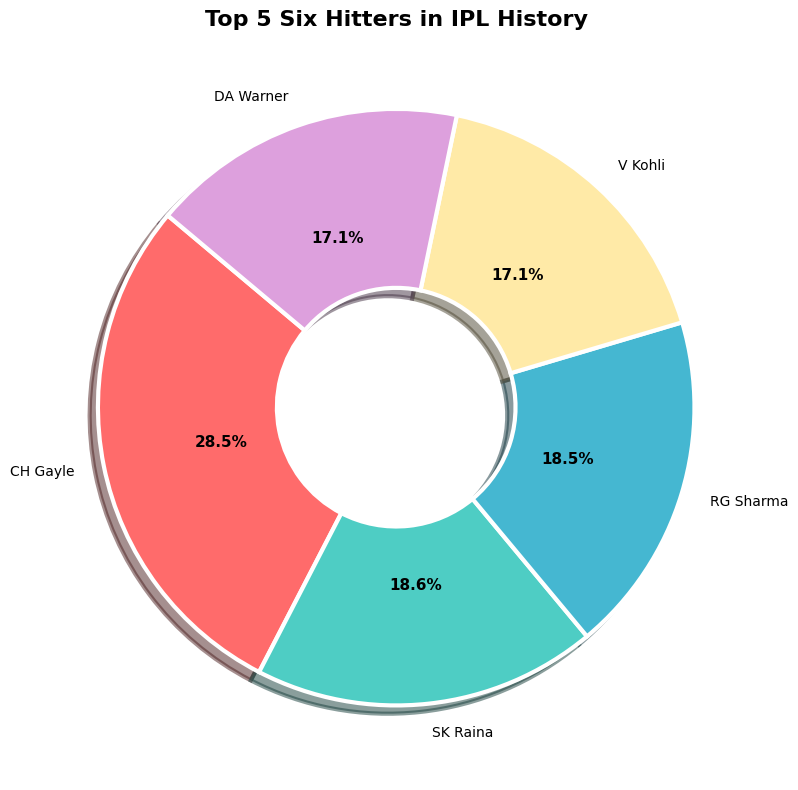

In [27]:
# Top 5 Six Hitters - Donut Chart
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFEAA7', '#DDA0DD']

wedges, texts, autotexts = ax.pie(
    most_sixes['total_sixes'],
    labels=most_sixes['batsman'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    shadow=True,
    wedgeprops={'linewidth': 3, 'edgecolor': 'white', 'width': 0.6}
)

for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

plt.title('Top 5 Six Hitters in IPL History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

============ Season Wise Total Runs ==========

In [ ]:
matches_sorted = matches[['ID', 'Season']].copy()
matches_sorted['match_num'] = range(1, len(matches_sorted) + 1)

# Deliveries mein match_id 1,2,3... hai jo match number hai
deliveries['Season'] = deliveries['match_id'].map(
    dict(zip(matches_sorted['match_num'], matches_sorted['Season']))
)

season_runs = deliveries.groupby('Season')['total_runs'].sum().reset_index()
season_runs = season_runs.sort_values('Season')
print(season_runs)

     Season  total_runs
0      2012        2639
1      2013       23607
2      2014       19286
3      2015       17656
4      2016       18046
5      2017       18050
6      2018       17115
7      2019       18461
8   2020/21       17910
9      2021       17891
10     2022       23653


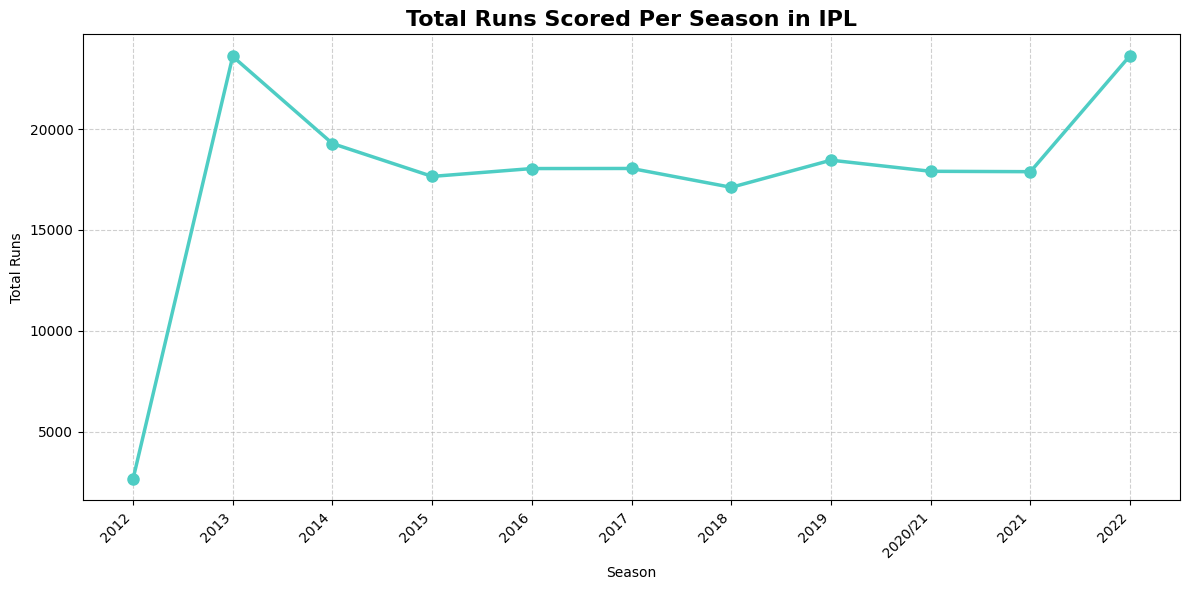

In [ ]:
# Season Wise Total Runs - Line Chart 
plt.figure(figsize=(12, 6))
plt.plot(range(len(season_runs)), season_runs['total_runs'],
         marker='o', color='#4ECDC4', linewidth=2.5, markersize=8)
plt.title('Total Runs Scored Per Season in IPL', fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(range(len(season_runs)), season_runs['Season'], rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

============ Player of the Match ============


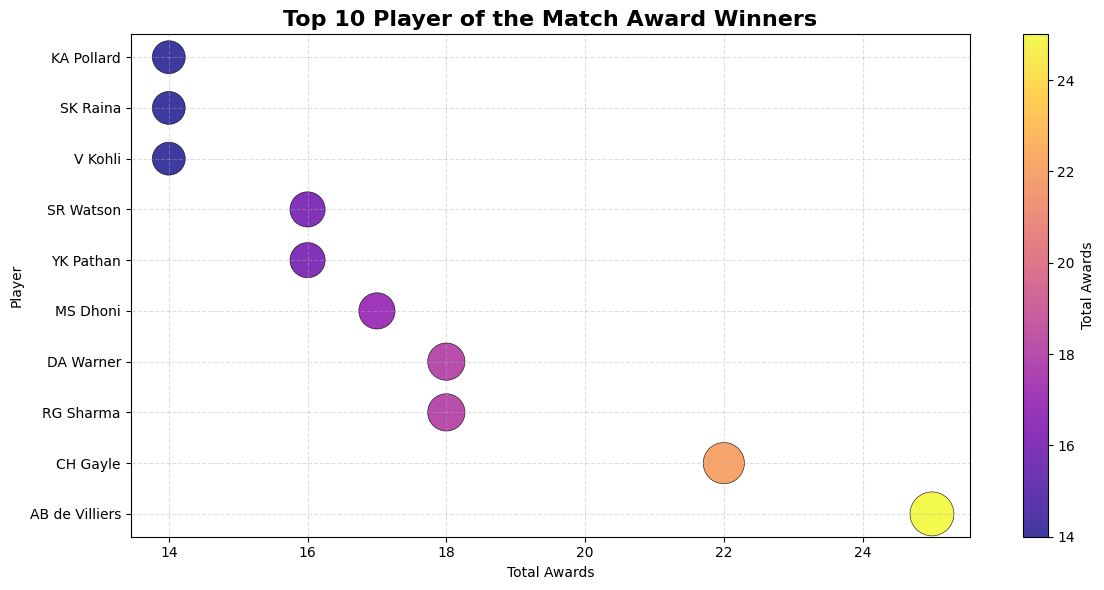

In [49]:
# Top 10 Player of the Match Award Winners - Scatter Plot
plt.figure(figsize=(12, 6))
plt.scatter(potm['total_awards'], potm['Player_of_Match'], 
            s=potm['total_awards']*40, 
            c=potm['total_awards'], 
            cmap='plasma', 
            alpha=0.8, 
            edgecolors='black', 
            linewidth=0.5)
plt.colorbar(label='Total Awards')
plt.title('Top 10 Player of the Match Award Winners', fontsize=16, fontweight='bold')
plt.xlabel('Total Awards')
plt.ylabel('Player')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

============ Toss Decision Analysis ============

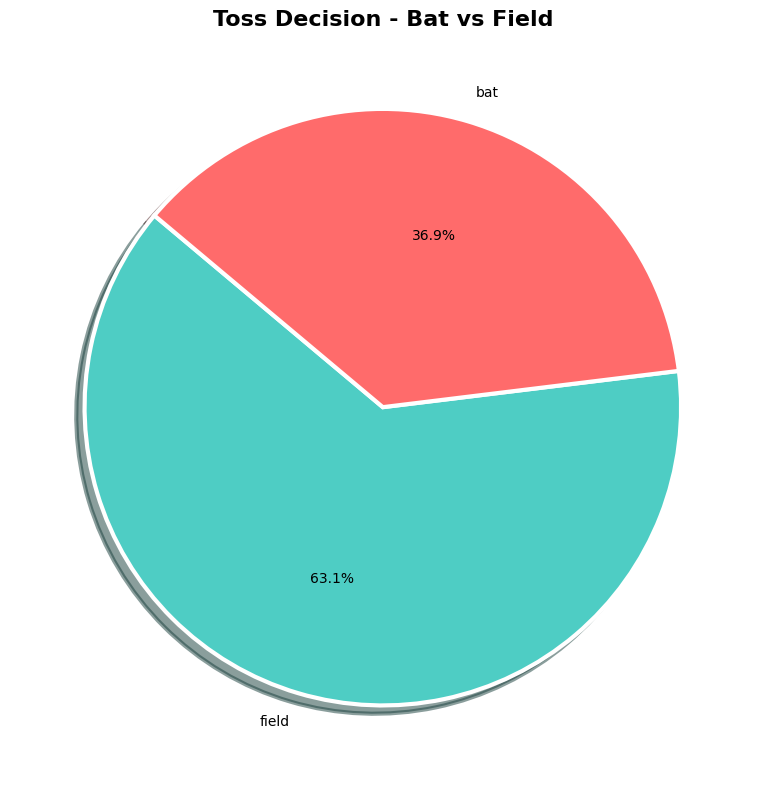

In [42]:
toss_decision = matches['TossDecision'].value_counts().reset_index()
toss_decision.columns = ['Decision', 'Count']

plt.figure(figsize=(8, 8))
plt.pie(toss_decision['Count'],
        labels=toss_decision['Decision'],
        autopct='%1.1f%%',
        colors=['#4ECDC4', '#FF6B6B'],
        startangle=140,
        shadow=True,
        wedgeprops={'linewidth': 3, 'edgecolor': 'white'})
plt.title('Toss Decision - Bat vs Field', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


============ Top 10 Venues by Matches Played ============


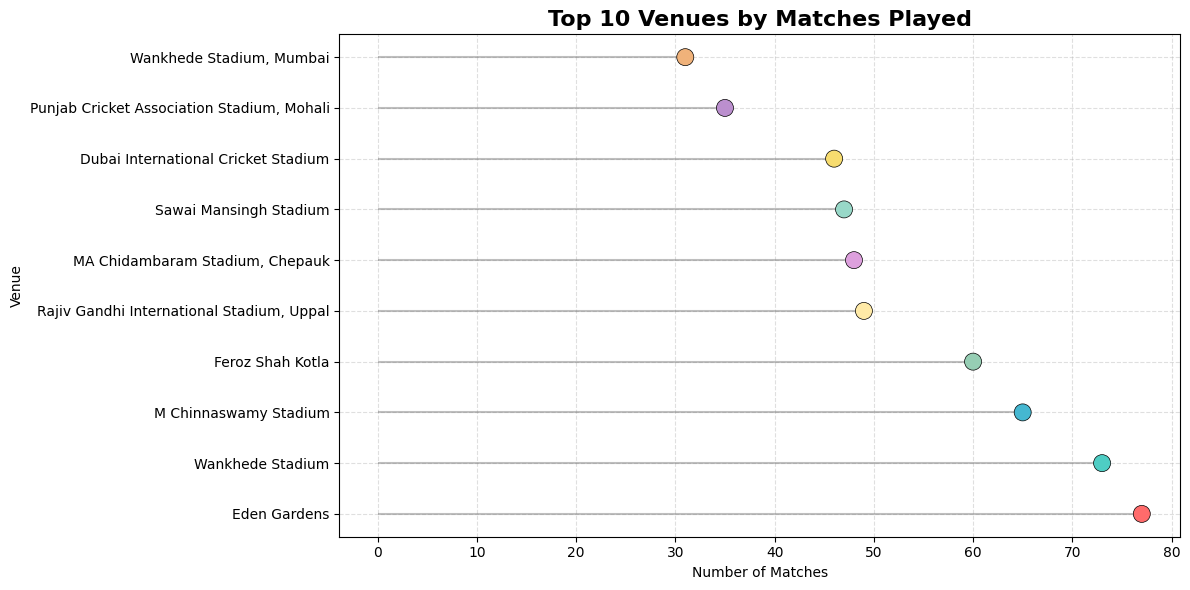

In [ ]:
plt.figure(figsize=(12, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7',
          '#DDA0DD', '#98D8C8', '#F7DC6F', '#BB8FCE', '#F0B27A']

plt.hlines(y=venues['Venue'], xmin=0, xmax=venues['Matches'], 
           color='grey', alpha=0.5, linewidth=1.5)
plt.scatter(venues['Matches'], venues['Venue'], 
            color=colors, s=150, zorder=5, edgecolors='black', linewidth=0.5)

plt.title('Top 10 Venues by Matches Played', fontsize=16, fontweight='bold')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

============ Most Fours by Player ============


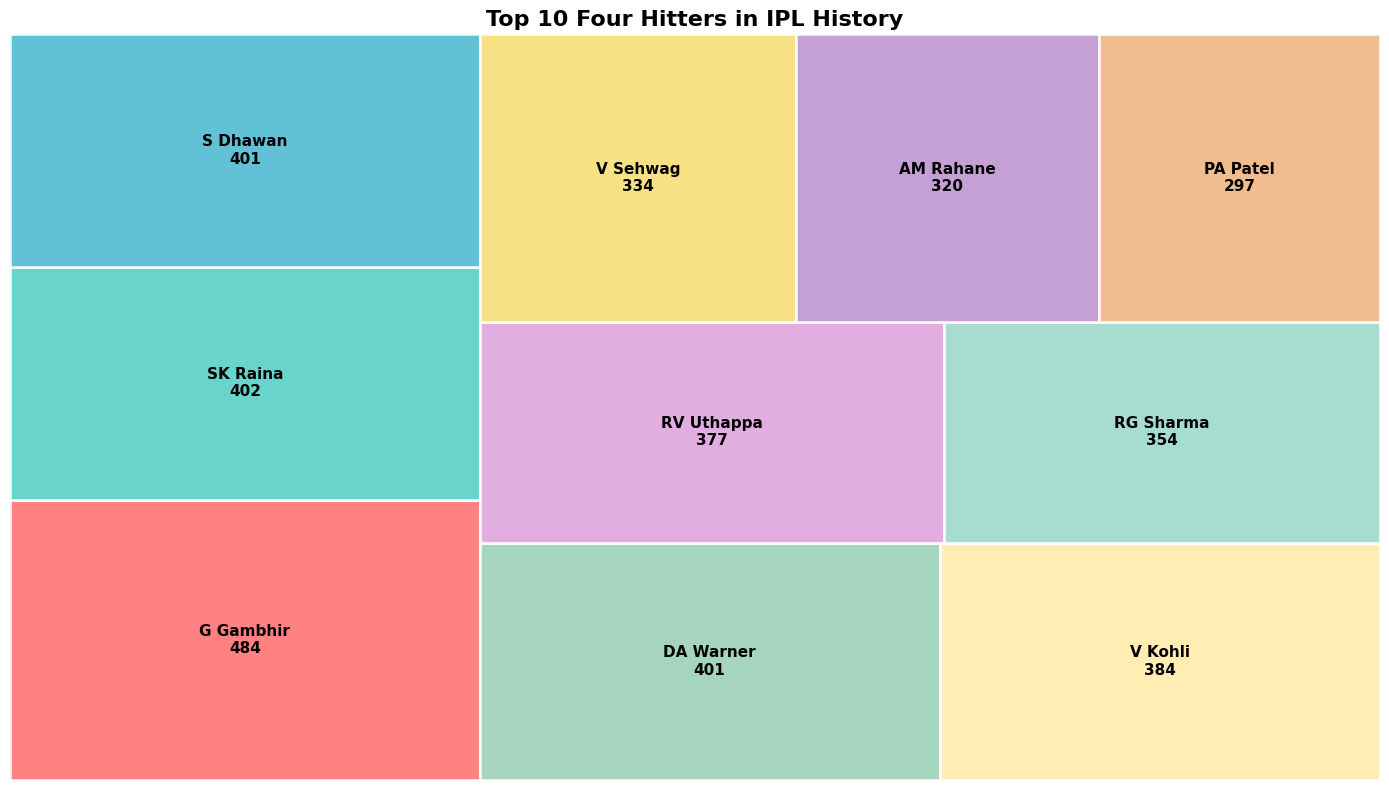

In [52]:
# Top 10 Four Hitters - Treemap
import squarify

plt.figure(figsize=(14, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7',
          '#DDA0DD', '#98D8C8', '#F7DC6F', '#BB8FCE', '#F0B27A']

squarify.plot(sizes=most_fours['total_fours'],
              label=[f"{row['batsman']}\n{row['total_fours']}" 
                     for _, row in most_fours.iterrows()],
              color=colors,
              alpha=0.85,
              edgecolor='white',
              linewidth=2,
              text_kwargs={'fontsize': 11, 'fontweight': 'bold'})

plt.title('Top 10 Four Hitters in IPL History', fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

============ Win by Runs vs Win by Wickets ============


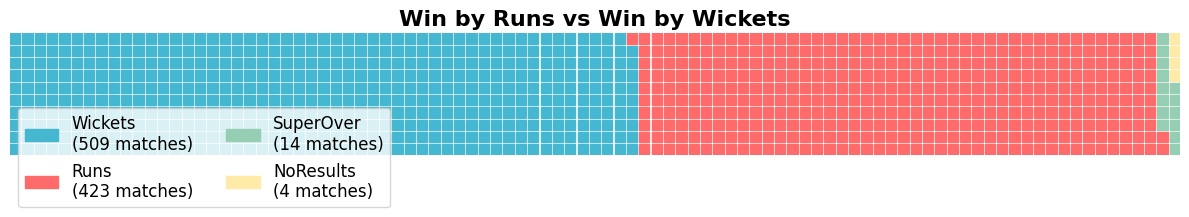

In [55]:
# Win by Runs vs Win by Wickets - Waffle Chart with Values
from pywaffle import Waffle

win_counts = matches['WonBy'].value_counts()

data = {f"{k}\n({v} matches)": v for k, v in win_counts.items()}

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    values=data,
    colors=['#45B7D1', '#FF6B6B', '#96CEB4', '#FFEAA7'],
    title={'label': 'Win by Runs vs Win by Wickets', 
           'loc': 'center',
           'fontsize': 16,
           'fontweight': 'bold'},
    legend={'loc': 'lower left', 
            'bbox_to_anchor': (0, -0.5), 
            'ncol': 2,
            'fontsize': 12},
    figsize=(12, 6)
)
plt.tight_layout()
plt.show()

============ Most Wins by Team - Heatmap ============


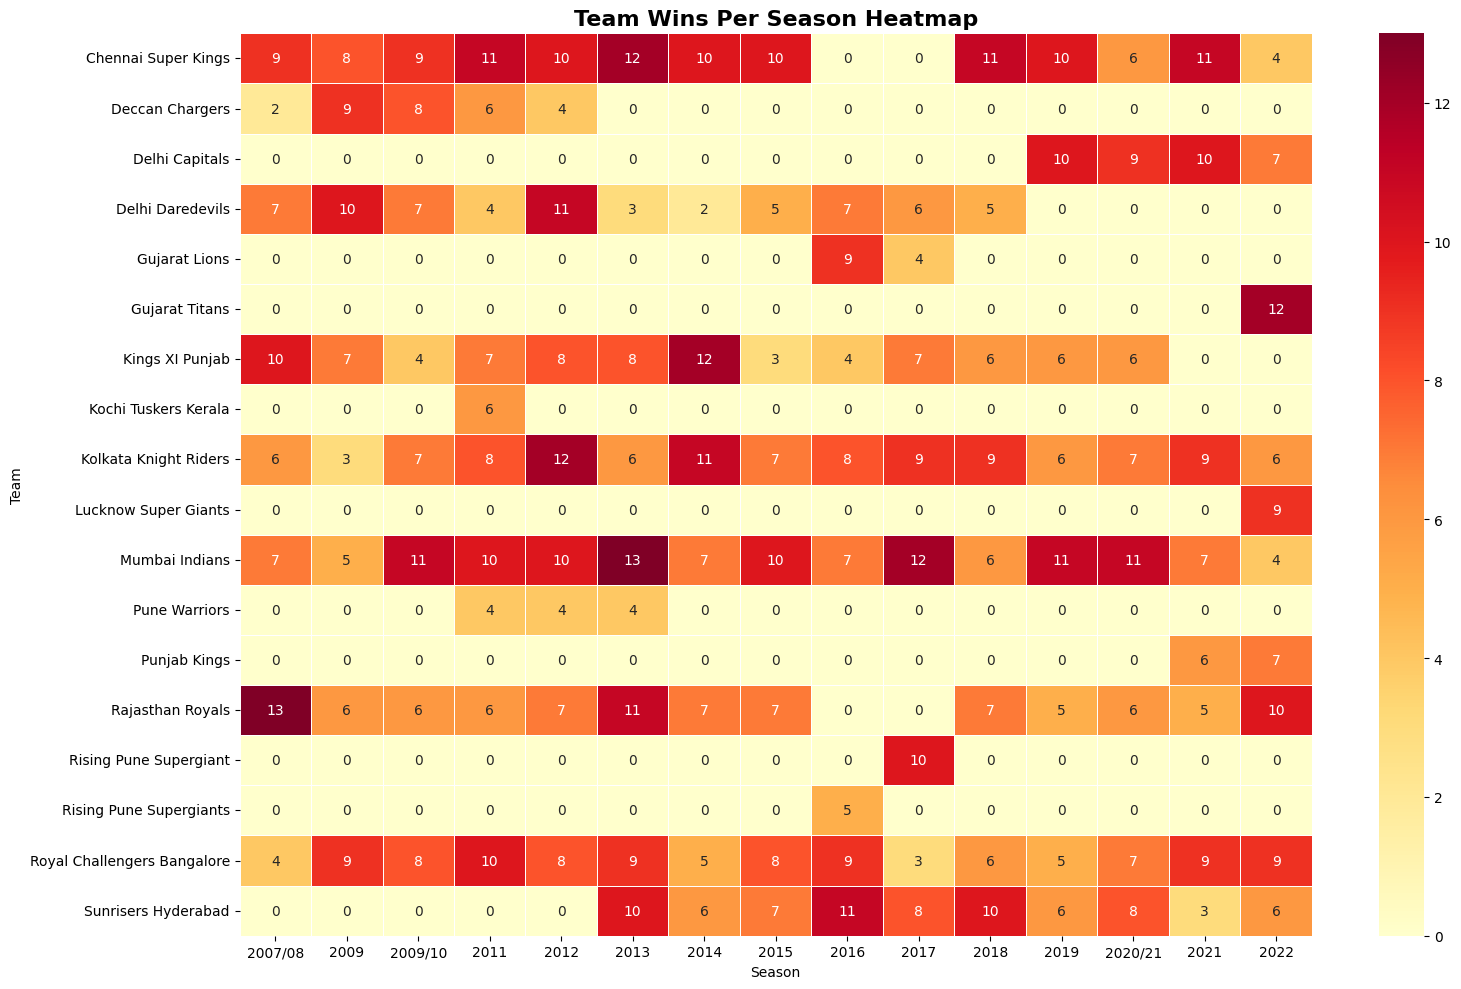

In [46]:
team_season = matches.groupby(['Season', 'WinningTeam']).size().reset_index(name='Wins')
team_pivot = team_season.pivot(index='WinningTeam', columns='Season', values='Wins').fillna(0)

plt.figure(figsize=(16, 10))
sns.heatmap(team_pivot, cmap='YlOrRd', linewidths=0.5, annot=True, fmt='.0f')
plt.title('Team Wins Per Season Heatmap', fontsize=16, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Team')
plt.tight_layout()
plt.show()


In [48]:
# ============ Closing the Database ============
conn.close()
print("Analysis Complete! ")

Analysis Complete! 
